In [1]:
%matplotlib inline
import pandas as pd
import sys
sys.path.append("..")
from scripts.radar_chart import plot_radar

df = pd.read_csv("../data/clean/ranked_central_midfields.csv")



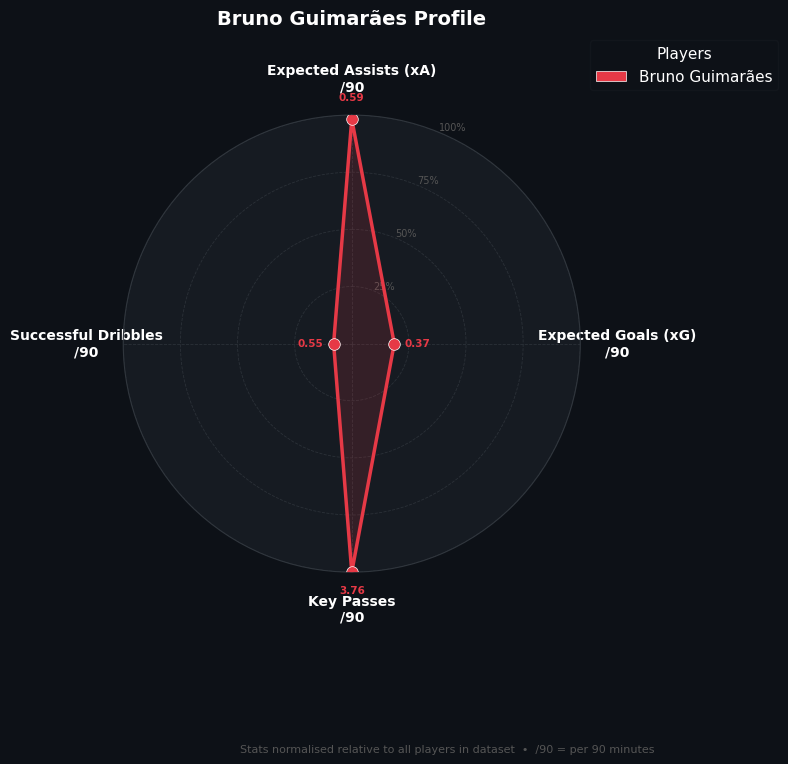

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Bruno Guimarães Profile'}>)

In [2]:
plot_radar(
    df,
    players=["Bruno Guimarães"],
    role="Central Midfield / Mezzala",
    title="Bruno Guimarães Profile",
)

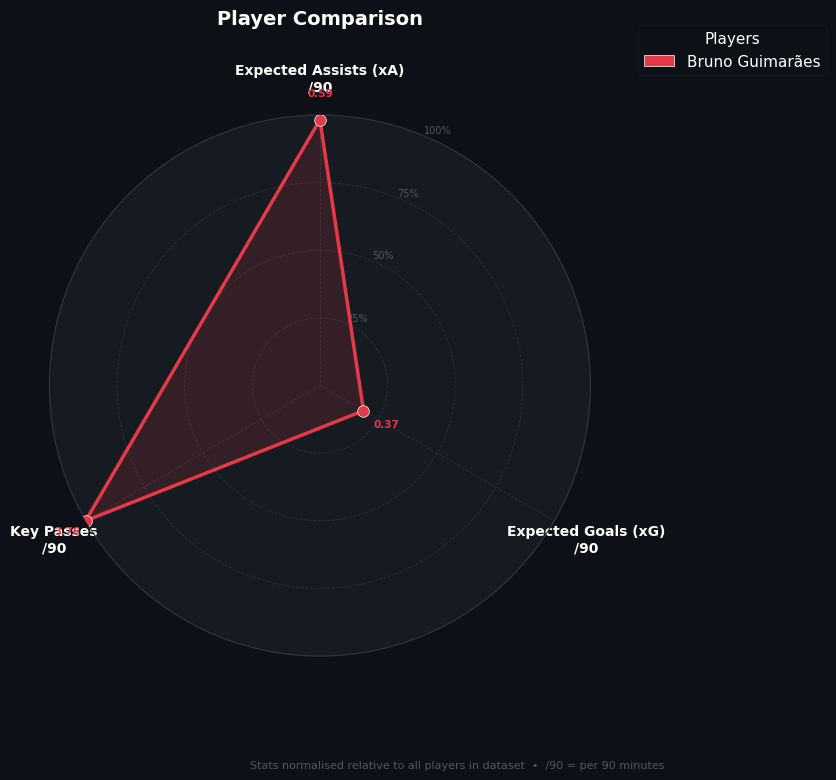

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Player Comparison'}>)

In [5]:
plot_radar(
    df,
    players=["Bruno Guimarães"],
    stats=[
        "Expected Assists (xA) (Per90)",
        "Expected Goals (xG) (Per90)",
        "Key Passes (Per90)"
    ],
)

 Performance vs Market Value

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the classified data
outfield_df = pd.read_csv("../data/clean/classified_outfield_players.csv")
goalkeeper_df = pd.read_csv("../data/clean/classified_goalkeepers.csv")

print(f"Loaded {len(outfield_df)} outfield players and {len(goalkeeper_df)} goalkeepers")

# Function to get role-specific performance score
def get_role_performance_score(row, player_type='outfield'):
    if player_type == 'outfield':
        role = row['Tactical_Role']
        # Map role to its corresponding score column
        role_score_map = {
            'Ball Playing Defender': 'Ball Playing Defender_Score',
            'Defensive Sweeper': 'Defensive Sweeper_Score',
            'Wing Back': 'Wing Back_Score',
            'Inverted Full Back': 'Inverted Full Back_Score',
            'Defensive Full Back': 'Defensive Full Back_Score',
            'Anchor Man': 'Anchor Man_Score',
            'Deep Lying Playmaker': 'Deep Lying Playmaker_Score',
            'Ball Winning Midfielder': 'Ball Winning Midfielder_Score',
            'Mezzala': 'Mezzala_Score',
            'Shadow Striker': 'Shadow Striker_Score',
            'Playmaker': 'Playmaker_Score',
            'Inside Forward': 'Inside Forward_Score',
            'Traditional Winger': 'Traditional Winger_Score',
            'Poacher': 'Poacher_Score',
            'Target Man': 'Target Man_Score',
            'False Nine': 'False Nine_Score',
            'Aerial Stopper': 'Aerial Stopper_Score'
        }
        
        # Handle combined roles (take the first available score)
        if '/' in role:
            possible_roles = role.split(' / ')
            for r in possible_roles:
                if r in role_score_map and role_score_map[r] in row and pd.notna(row[role_score_map[r]]):
                    return row[role_score_map[r]]
        else:
            if role in role_score_map and role_score_map[role] in row:
                return row[role_score_map[role]]
    
    elif player_type == 'goalkeeper':
        # For goalkeepers, use both scores
        shot_score = row.get('Shot Stopper_Score', np.nan)
        sweeper_score = row.get('Sweeper Keeper_Score', np.nan)
        if pd.notna(shot_score) and pd.notna(sweeper_score):
            return (shot_score + sweeper_score) / 2
        elif pd.notna(shot_score):
            return shot_score
        elif pd.notna(sweeper_score):
            return sweeper_score
    
    return np.nan

# Function to map tactical roles to traditional positions
def map_to_traditional_position(row, player_type='outfield'):
    if player_type == 'outfield':
        role = row['Tactical_Role']
        
        # Map tactical roles to traditional positions
        defensive_roles = [
            'Ball Playing Defender', 'Defensive Sweeper', 'Wing Back',
            'Inverted Full Back', 'Defensive Full Back', 'Aerial Stopper'
        ]
        
        midfield_roles = [
            'Anchor Man', 'Deep Lying Playmaker', 'Ball Winning Midfielder',
            'Mezzala', 'Shadow Striker', 'Playmaker'
        ]
        
        attacking_roles = [
            'Inside Forward', 'Traditional Winger', 'Poacher',
            'Target Man', 'False Nine'
        ]
        
        # Handle combined roles
        if '/' in role:
            possible_roles = role.split(' / ')
            for r in possible_roles:
                if r in defensive_roles:
                    return 'Defender'
                elif r in midfield_roles:
                    return 'Midfielder'
                elif r in attacking_roles:
                    return 'Forward'
        else:
            if role in defensive_roles:
                return 'Defender'
            elif role in midfield_roles:
                return 'Midfielder'
            elif role in attacking_roles:
                return 'Forward'
    
    elif player_type == 'goalkeeper':
        return 'Goalkeeper'
    
    return 'Unknown'

# Apply role-specific performance scores
outfield_df['Role_Performance_Score'] = outfield_df.apply(lambda row: get_role_performance_score(row, 'outfield'), axis=1)
goalkeeper_df['Role_Performance_Score'] = goalkeeper_df.apply(lambda row: get_role_performance_score(row, 'goalkeeper'), axis=1)

# Map to traditional positions
outfield_df['Traditional_Position'] = outfield_df.apply(lambda row: map_to_traditional_position(row, 'outfield'), axis=1)
goalkeeper_df['Traditional_Position'] = goalkeeper_df.apply(lambda row: map_to_traditional_position(row, 'goalkeeper'), axis=1)

# Remove players with missing data
outfield_clean = outfield_df.dropna(subset=['Role_Performance_Score', 'Market Value'])
gk_clean = goalkeeper_df.dropna(subset=['Role_Performance_Score', 'Market Value'])

print(f"Clean data: {len(outfield_clean)} outfield players, {len(gk_clean)} goalkeepers")

# Show position distribution
all_players = pd.concat([
    outfield_clean.assign(Player_Type='Outfield'),
    gk_clean.assign(Player_Type='Goalkeeper')
], ignore_index=True)

position_dist = all_players['Traditional_Position'].value_counts()
print(f"\nPosition Distribution:")
for pos, count in position_dist.items():
    print(f"  {pos}: {count} players")

Loaded 772 outfield players and 52 goalkeepers
Clean data: 772 outfield players, 52 goalkeepers

Position Distribution:
  Defender: 294 players
  Forward: 241 players
  Midfielder: 237 players
  Goalkeeper: 52 players


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20904\3078930633.py:116: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\lenovo\miniconda3\envs\football\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


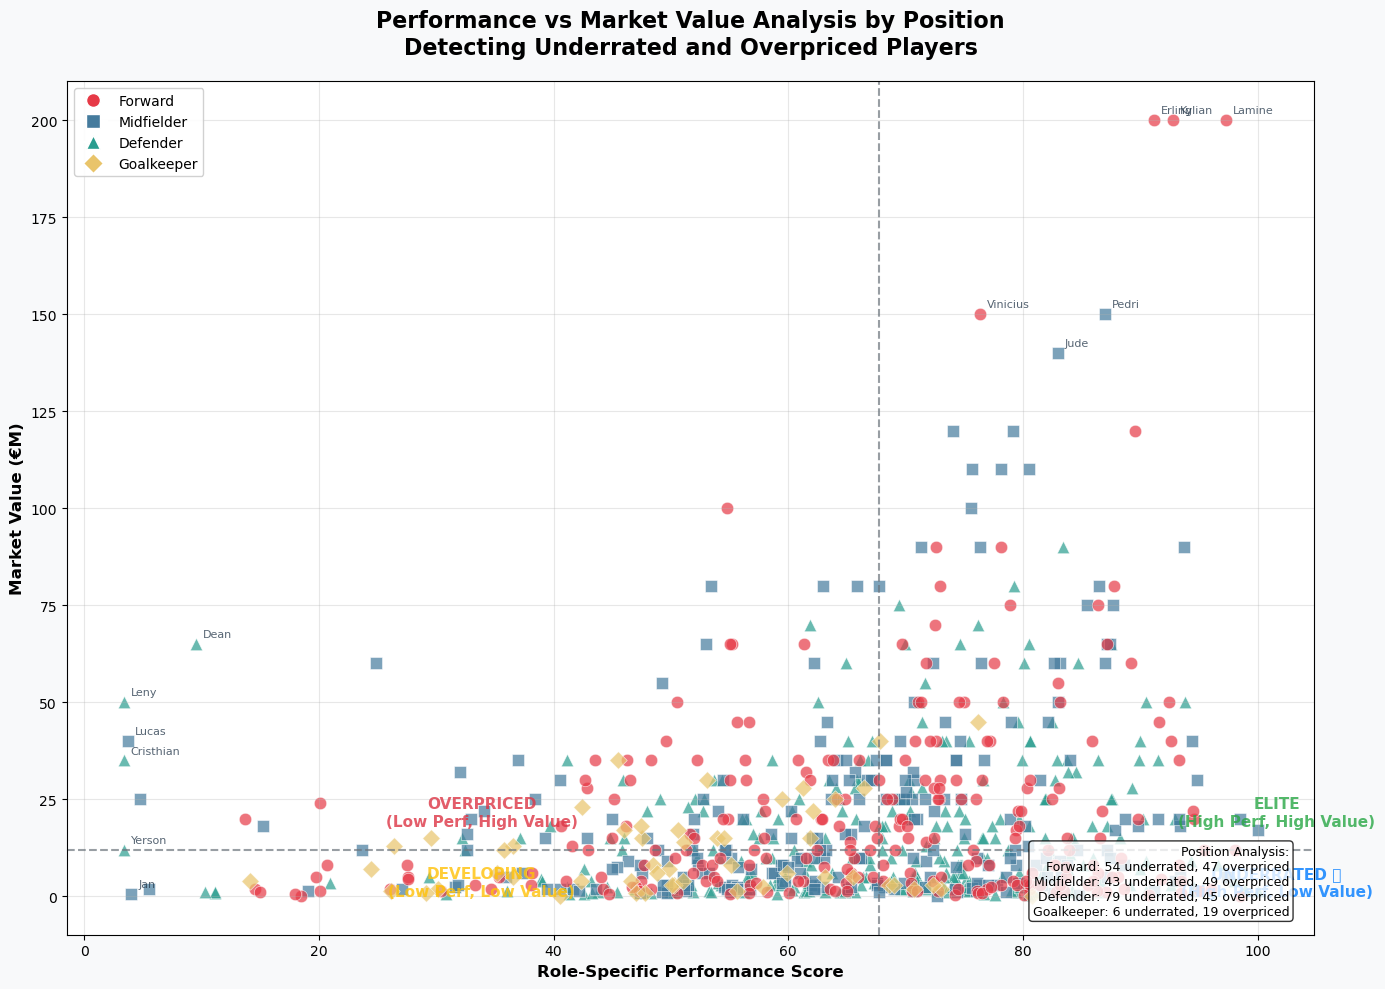

In [ ]:
# Combine data for plotting
all_players = pd.concat([
    outfield_clean.assign(Player_Type='Outfield'),
    gk_clean.assign(Player_Type='Goalkeeper')
], ignore_index=True)

# Define colors for traditional positions
position_colors = {
    'Forward': '#e63946',      # Red
    'Midfielder': '#457b9d',  # Blue  
    'Defender': '#2a9d8f',    # Green
    'Goalkeeper': '#e9c46a',  # Yellow
    'Unknown': '#adb5bd'      # Gray
}

position_markers = {
    'Forward': 'o',
    'Midfielder': 's', 
    'Defender': '^',
    'Goalkeeper': 'D',
    'Unknown': 'x'
}

# Create the scatter plot
fig, ax = plt.subplots(figsize=(14, 10), facecolor='#f8f9fa')
ax.set_facecolor('#ffffff')

# Plot each position with different colors and markers
for position in all_players['Traditional_Position'].unique():
    if position == 'Unknown':
        continue
        
    position_data = all_players[all_players['Traditional_Position'] == position]
    
    ax.scatter(
        position_data['Role_Performance_Score'],
        position_data['Market Value'] / 1e6,  # Convert to millions
        c=position_colors[position], 
        alpha=0.7, 
        s=80, 
        edgecolors='white', 
        linewidth=0.5,
        label=position,
        marker=position_markers[position]
    )

# Add quadrant lines (median values)
median_perf = all_players['Role_Performance_Score'].median()
median_value = (all_players['Market Value'] / 1e6).median()

ax.axvline(median_perf, color='#6c757d', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axhline(median_value, color='#6c757d', linestyle='--', alpha=0.7, linewidth=1.5)

# Add quadrant labels
ax.text(median_perf * 0.5, median_value * 1.8, 'OVERPRICED\n(Low Perf, High Value)', 
        ha='center', va='center', fontsize=11, color='#dc3545', fontweight='bold', alpha=0.8)
ax.text(median_perf * 1.5, median_value * 1.8, 'ELITE\n(High Perf, High Value)', 
        ha='center', va='center', fontsize=11, color='#28a745', fontweight='bold', alpha=0.8)
ax.text(median_perf * 0.5, median_value * 0.3, 'DEVELOPING\n(Low Perf, Low Value)', 
        ha='center', va='center', fontsize=11, color='#ffc107', fontweight='bold', alpha=0.8)
ax.text(median_perf * 1.5, median_value * 0.3, 'UNDERRATED ⭐\n(High Perf, Low Value)', 
        ha='center', va='center', fontsize=11, color='#007bff', fontweight='bold', alpha=0.8)

# Label top 12 most extreme players (potential bargains or overpriced)
extremeness = np.sqrt(
    ((all_players['Role_Performance_Score'] - median_perf) / (all_players['Role_Performance_Score'].max() - all_players['Role_Performance_Score'].min()))**2 +
    (((all_players['Market Value'] / 1e6) - median_value) / ((all_players['Market Value'] / 1e6).max() - (all_players['Market Value'] / 1e6).min()))**2
)

top_indices = extremeness.nlargest(12).index
for idx in top_indices:
    player = all_players.loc[idx]
    ax.annotate(
        player['Name'].split()[0],  # First name only for space
        xy=(player['Role_Performance_Score'], player['Market Value'] / 1e6),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, alpha=0.8, color='#2c3e50'
    )

# Styling
ax.set_xlabel('Role-Specific Performance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Market Value (€M)', fontsize=12, fontweight='bold')
ax.set_title('Performance vs Market Value Analysis by Position\nDetecting Underrated and Overpriced Players', 
             fontsize=16, fontweight='bold', pad=20)

# Create custom legend
legend_elements = []
for position, color in position_colors.items():
    if position != 'Unknown' and position in all_players['Traditional_Position'].values:
        legend_elements.append(plt.Line2D([0], [0], marker=position_markers[position], color='w', 
                                          markerfacecolor=color, markersize=10, label=position))

ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9, fontsize=10)
ax.grid(True, alpha=0.3)

# Add statistics text by position
stats_text = "Position Analysis:\n"
for position in ['Forward', 'Midfielder', 'Defender', 'Goalkeeper']:
    pos_data = all_players[all_players['Traditional_Position'] == position]
    underrated = len(pos_data[
        (pos_data['Role_Performance_Score'] > median_perf) & 
        ((pos_data['Market Value'] / 1e6) < median_value)
    ])
    overpriced = len(pos_data[
        (pos_data['Role_Performance_Score'] < median_perf) & 
        ((pos_data['Market Value'] / 1e6) > median_value)
    ])
    stats_text += f"{position}: {underrated} underrated, {overpriced} overpriced\n"

ax.text(0.98, 0.02, stats_text.strip(), transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Role Comparison

In [57]:
# Compare players across tactical roles with detailed breakdowns

import sys
sys.path.append("..")
from scripts.config import outfield_config, gk_config

# Load the classified data
outfield_df = pd.read_csv("../data/clean/classified_outfield_players.csv")
goalkeeper_df = pd.read_csv("../data/clean/classified_goalkeepers.csv")

print(f"Loaded {len(outfield_df)} outfield players and {len(goalkeeper_df)} goalkeepers")

# Function to get all tactical roles from config
def get_all_tactical_roles():
    roles = []
    for position_config in outfield_config.values():
        for role_name in position_config.keys():
            if role_name != "Positions":
                roles.append(role_name)
    
    # Add goalkeeper roles
    for gk_position_config in gk_config.values():
        for role_name in gk_position_config.keys():
            if role_name != "Positions":
                roles.append(role_name)
    
    return roles

# Function to map tactical role to traditional position using config
def map_role_to_position_from_config(tactical_role):
    for position_name, position_config in outfield_config.items():
        if tactical_role in position_config and tactical_role != "Positions":
            return position_name.replace("-", " ")  # Convert "Centre-Back" to "Centre Back"
    
    # Check goalkeeper roles
    for gk_position_name, gk_position_config in gk_config.items():
        if tactical_role in gk_position_config and tactical_role != "Positions":
            return gk_position_name
    
    return "Unknown"

# Get role information
all_tactical_roles = get_all_tactical_roles()
print(f"Found {len(all_tactical_roles)} tactical roles in config:")
for role in sorted(all_tactical_roles):
    position = map_role_to_position_from_config(role)
    print(f"  {role} → {position}")

Loaded 772 outfield players and 52 goalkeepers
Found 20 tactical roles in config:
  Aerial Stopper → Centre Back
  Anchor Man → Defensive Midfield
  Ball Playing Defender → Centre Back
  Ball Winning Midfielder → Defensive Midfield
  Ball Winning Midfielder → Defensive Midfield
  Deep Lying Playmaker → Defensive Midfield
  Defensive Full Back → Full Back
  Defensive Sweeper → Centre Back
  False Nine → Striker
  Inside Forward → Winger
  Inverted Full Back → Full Back
  Mezzala → Central Midfield
  Playmaker → Attacking Midfield
  Poacher → Striker
  Shadow Striker → Attacking Midfield
  Shot Stopper → Goalkeeper
  Sweeper Keeper → Goalkeeper
  Target Man → Striker
  Traditional Winger → Winger
  Wing Back → Full Back


In [59]:
selected_player = "William saliba"  # Change this to any player you want to analyze


player_data = outfield_df[outfield_df['Name'].str.contains(selected_player, case=False, na=False)]

if player_data.empty:
    print(f"Player '{selected_player}' not found in outfield dataset. Let's pick another player.")
    # Pick a random player as example
    selected_player = outfield_df['Name'].iloc[0]
    player_data = outfield_df[outfield_df['Name'] == selected_player]
    print(f"Using {selected_player} instead.")

player_row = player_data.iloc[0]
current_tactical_role = player_row['Tactical_Role']
current_position = map_role_to_position_from_config(current_tactical_role)

print(f" PLAYER ANALYSIS: {selected_player}")
print(f"Current Tactical Role: {current_tactical_role}")
print(f"Traditional Position: {current_position}")
print(f"Market Value: €{player_row['Market Value']/1e6:.1f}M")

# Get player's scores for all tactical roles
player_role_scores = {}
for role in all_tactical_roles:
    score_col = f"{role}_Score"
    if score_col in player_row and pd.notna(player_row[score_col]):
        player_role_scores[role] = player_row[score_col]

print(f"\n Available Role Scores:")
for role, score in sorted(player_role_scores.items(), key=lambda x: x[1], reverse=True):
    current = " ← CURRENT" if role == current_tactical_role else ""
    print(f"  {role}: {score:.1f}{current}")

 PLAYER ANALYSIS: William saliba
Current Tactical Role: Ball Playing Defender
Traditional Position: Centre Back
Market Value: €90.0M

 Available Role Scores:
  Ball Playing Defender: 83.4 ← CURRENT
  Aerial Stopper: 48.4
  Defensive Sweeper: 35.5


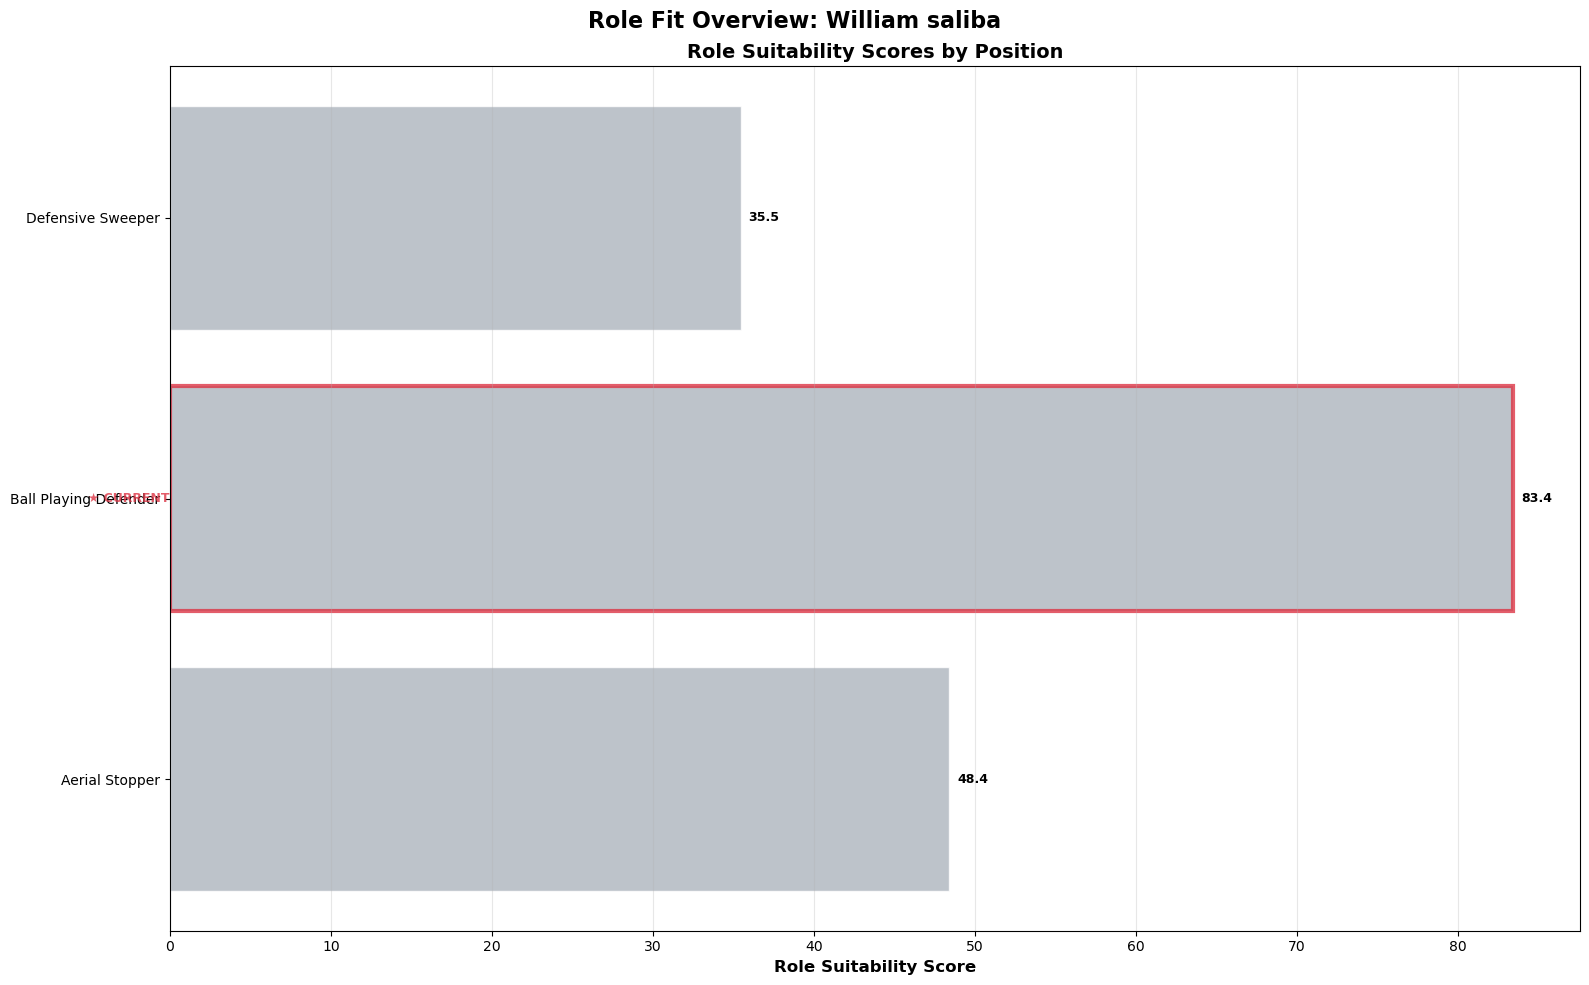

In [53]:
# Role Fit Overview - Using config.py Structure
# Compare player suitability across all tactical roles organized by traditional positions

# Create role fit overview
fig, ax = plt.subplots(figsize=(16, 10))
fig.suptitle(f'Role Fit Overview: {selected_player}', fontsize=16, fontweight='bold')

# Left plot: Role suitability scores by position
position_colors = {
    'Centre Back': '#2a9d8f',
    'Full Back': '#2a9d8f', 
    'Defensive Midfield': '#457b9d',
    'Central Midfield': '#457b9d',
    'Attacking Midfield': '#457b9d',
    'Winger': '#e63946',
    'Striker': '#e63946',
    'Goalkeeper': '#e9c46a'
}

# Organize roles by position
position_role_scores = {}
for position_name, position_config in outfield_config.items():
    position_role_scores[position_name] = {}
    for role_name in position_config.keys():
        if role_name != "Positions" and role_name in player_role_scores:
            position_role_scores[position_name][role_name] = player_role_scores[role_name]

# Add goalkeeper roles
for gk_position_name, gk_position_config in gk_config.items():
    position_role_scores[gk_position_name] = {}
    for role_name in gk_position_config.keys():
        if role_name != "Positions" and role_name in player_role_scores:
            position_role_scores[gk_position_name][role_name] = player_role_scores[role_name]

# Create bar chart
all_roles = []
all_scores = []
all_colors = []
all_positions = []

for position, roles in position_role_scores.items():
    if roles:  # Only include positions with available scores
        for role, score in roles.items():
            all_roles.append(role)
            all_scores.append(score)
            all_colors.append(position_colors.get(position, '#adb5bd'))
            all_positions.append(position)

if all_scores:
    bars = ax.barh(range(len(all_roles)), all_scores, color=all_colors, alpha=0.8, edgecolor='white', linewidth=1)
    ax.set_yticks(range(len(all_roles)))
    ax.set_yticklabels(all_roles)
    ax.set_xlabel('Role Suitability Score', fontsize=12, fontweight='bold')
    ax.set_title('Role Suitability Scores by Position', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels and highlight current role
    for i, (bar, score, role) in enumerate(zip(bars, all_scores, all_roles)):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{score:.1f}', va='center', fontsize=9, fontweight='bold')
        
        if role == current_tactical_role:
            bar.set_edgecolor('#dc3545')
            bar.set_linewidth(3)
            ax.text(0, i, '★ CURRENT', va='center', ha='right', fontsize=9, 
                    color='#dc3545', fontweight='bold', alpha=0.8)

plt.tight_layout()
plt.show()